# GMM Clustering for Astronomical Objects

In this notebook, we apply Gaussian Mixture Models (GMM) to cluster stars, galaxies, and quasars based on their photometric properties. We follow the preprocessing steps identified in the preliminary analysis.

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix

sns.set_style("whitegrid")
np.random.seed(42)

## 1. Load and Preprocess Data

In [57]:
df = pd.read_csv("star-galaxy-quasar.csv", comment="#")

# Feature Engineering: Color Indices
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]

# Remove missing value placeholders (-9999)
df = df[(df[["u", "g", "r", "i", "z"]] > -1000).all(axis=1)]

# Prepare features and labels
X = df.drop(columns=["objid", "class"])
y_true = df["class"]

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for Dimensionality Reduction (6 components capture ~95% variance)
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

print(f"Original shape: {X.shape}")
print(f"PCA shape: {X_pca.shape}")

Original shape: (9985, 12)
PCA shape: (9985, 6)


## 2. GMM Clustering

We know there are 3 classes (STAR, GALAXY, QSO), so we start with `n_component=3`.

In [58]:
gmm = GaussianMixture(n_components=3, covariance_type="full", random_state=42)
clusters = gmm.fit_predict(X_pca)

df["cluster"] = clusters

## 3. Evaluation

In [59]:
# External Evaluation Metrics
ari = adjusted_rand_score(y_true, clusters)
nmi = normalized_mutual_info_score(y_true, clusters)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.4110
Normalized Mutual Information (NMI): 0.3507


In [60]:
# By inspecting the data, we can map the clusters to the a string representation
label_map = {0: "QSO", 1: "STAR", 2: "GALAXY"}

clusters_str = [label_map[x] for x in clusters]

In [61]:
cm = confusion_matrix(y_true, clusters_str)

In [62]:
accuracy = sum([1 for x, y in zip(y_true, clusters_str) if x == y]) / len(y_true)
print(accuracy)

0.8037055583375062


In [63]:
cm_prop = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_prop


array([[0.80557202, 0.01232958, 0.1820984 ],
       [0.0350365 , 0.87883212, 0.08613139],
       [0.20231214, 0.0716763 , 0.72601156]])

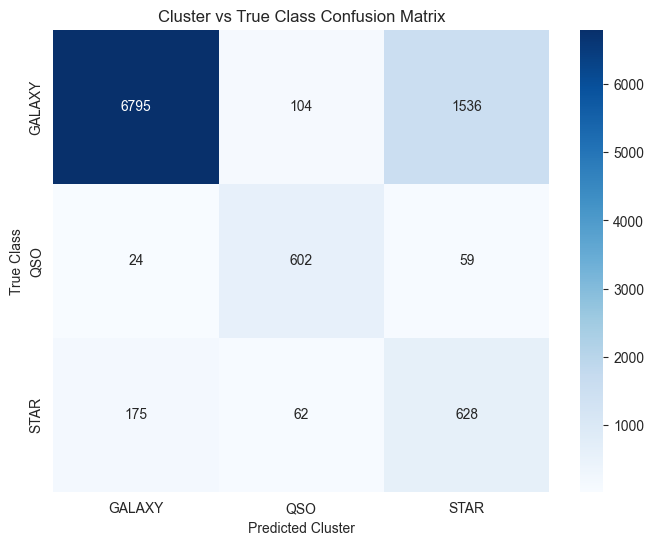

In [64]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    yticklabels=["GALAXY", "QSO", "STAR"],
    xticklabels=["GALAXY", "QSO", "STAR"],
)

plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.title("Cluster vs True Class Confusion Matrix")
plt.show()

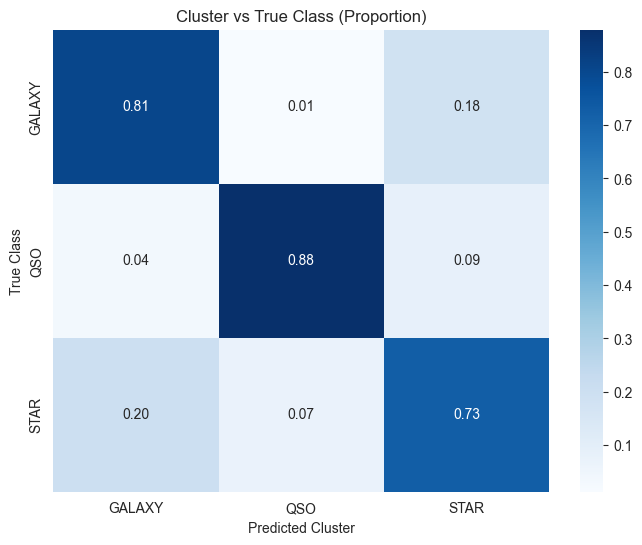

In [65]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_prop,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    yticklabels=["GALAXY", "QSO", "STAR"],
    xticklabels=["GALAXY", "QSO", "STAR"],
)

plt.xlabel("Predicted Cluster")
plt.ylabel("True Class")
plt.title("Cluster vs True Class (Proportion)")
plt.show()

## 4. Visualization in PCA Space

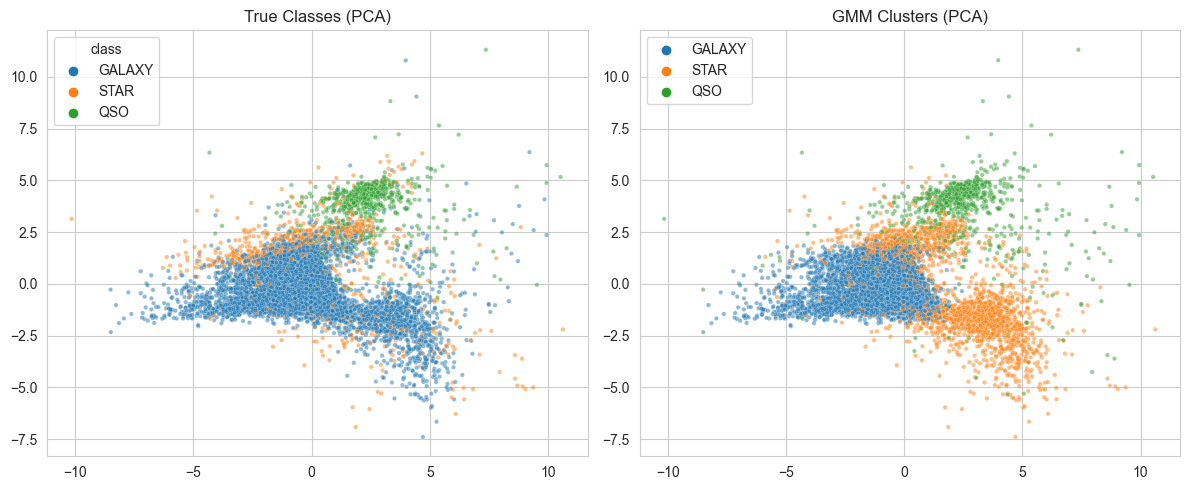

In [66]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, alpha=0.5, s=10)
plt.title("True Classes (PCA)")

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters_str, alpha=0.5, s=10)
plt.title("GMM Clusters (PCA)")

plt.tight_layout()
plt.show()